In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml

In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X matrix shape:  (70000, 784)
amount of unique y marks:  10


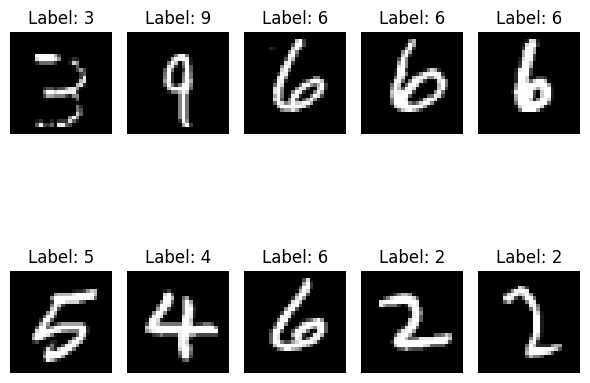

In [18]:
print("X matrix shape: ", X.shape)
print("amount of unique y marks: ", len(np.unique(y)))
plt.figure(figsize=(6, 6))
rand_index = np.random.choice(X.shape[0], 10, replace=False)
for i, ind in enumerate(rand_index):
    plt.subplot(2, 5, i + 1)
    image = X[ind].reshape(28, 28)
    plt.imshow(image, cmap=plt.cm.gray)
    plt.title(f"Label: {y[ind]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i}: {ratio}")

PC0: 0.09746115922494752
PC1: 0.07155444586878709
PC2: 0.06149530980723029


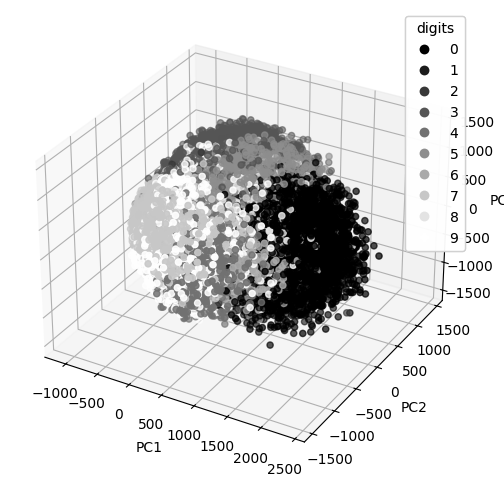

In [21]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=y.astype(int), cmap=plt.cm.gray)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
legend = ax.legend(*scatter.legend_elements(), title="digits")
ax.add_artist(legend)
plt.show()
